# Exploratory Data Analysis: Loan Default

## Objective

This project explores a dataset of a loan applications to identify patterns and 
relationships between borrower characteristics and loan default.

The analysis will investigate factors such as income, credit score, loan amount,
interest rate and debt-to-income ratio.

In [11]:
# IMPORT PANDAS, PLOTLY, NUMPY AND SEABORN

# !mamba install pandas
# !mamba install seaborn
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns

## 1. Dataset Overview

Before beginning the analysis, I will examine the structure of the dataset and assess its overall quality.

In [12]:
#IMPORT THE LOAN DEFAULT DATASET
loan_dataset = pd.read_csv('data/Loan_default.csv')
loan_dataset.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [31]:
loan_dataset.shape

(255347, 18)

In [17]:
# LOOK AT THE COLUMNS
loan_dataset.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='str')

In [18]:
# WE CAN ASSESS THE DATATYPES OF EACH COLUMN
loan_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

### Initial Observations

The dataset contains 255,347 observations and 18 variables.

The dataset contains both numerical and categorical variables. The numerical variables include borrower and loan characteristics such as income, loan amount, credit score, interest rate and debt-to-income ratio.

There are no missing values reported across the 18 variables, as each column contains 255,347 non-null observations.

The 'LoanID' variable appears to be an identitifier, while 'Default' will be used to investigate loan default outcomes.

In [21]:
# CHECK FOR ANY DUPLICATE VALUES
loan_dataset.duplicated().sum()

np.int64(0)

In [20]:
# CHECK FOR ANY MISSING VALUES
loan_dataset.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

### Data Quality Assessment

The dataset contains 255,347 observations across 18 variables. 

The data quality checks identified no duplicate rows and no missing values across any of the variables.

As a result, no rows need to be removed due to missing or duplicate data at this stage of the analysis.

Approximately 11.6% of the loans in this dataset are recorded as defaults, while 88.4% are non-defaults.

## Question 1 - How common is loan default in the dataset?

Before investigating which borrower and loan characteristics may be associated with defualt, I will first exmaine the distribution of default outcomes in the dataset.


In [33]:
loan_dataset['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [34]:
loan_dataset['Default'].value_counts(normalize=True) * 100

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

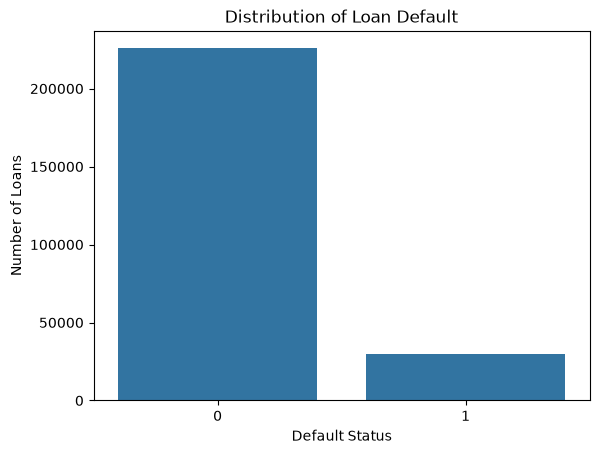

In [36]:
sns.countplot(data=loan_dataset, x="Default")

plt.title("Distribution of Loan Default")
plt.xlabel("Default Status")
plt.ylabel("Number of Loans")

plt.show()


### Observation

The dataset contains 255,347 loan records. Of these, 29,653 (approximately 11.6%) are recorded as defaults, while 225,694 (approximately 88.4%) are recorded as non-defaults.

This shows that default is the less common outcome in this dataset. The difference in the  number of default and non-default observations should be considered when interpreting comparisons between the two groups.

## Question 2 - Does loan amount differ between borrowers who defaulted and those who didn't?

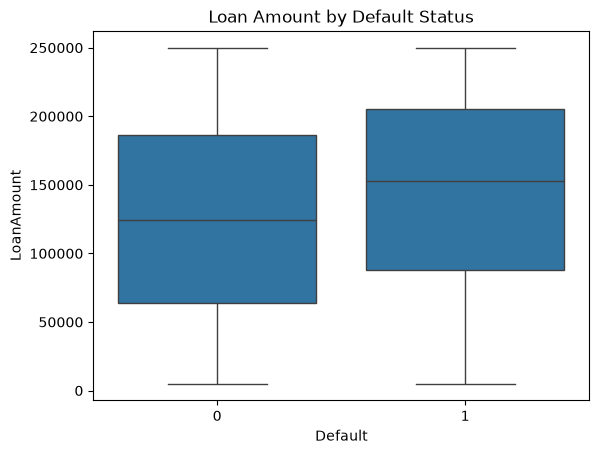

In [37]:
sns.boxplot(data=loan_dataset, x="Default", y="LoanAmount")

plt.title("Loan Amount by Default Status")
plt.show()

In [39]:
loan_dataset.groupby("Default")["LoanAmount"].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,125353.656017,70708.101479,5001.0,63889.25,124236.0,186177.75,249999.0
1,29653.0,144515.311469,69547.822943,5000.0,88085.00,152672.0,205468.00,249993.0


### Observation

The distribution of loan amounts differ between borrowers who defaulted and those who did not.

Borrowers who defaulted had higher median loan amount (£152,672) compared with borrowers who did not default (£124,236). The mean loan amount was also higher among borrowers who defaulted (approximately £144,515 compared with £125,354).

Although the distributions overlap considerably, the results suggest that higher loan amounts are associated with greater occurence of default in this dataset.

This analysis shows an association between loan amount and default, but it does not establish that a higher loan amount causes a borrower to default.

### Question 3 - Is credit score associated with loan default?

Credit score is an important measure of a borrower's credit profile. I will compare credit score distributions between borrwers who defaulted and those who did not.

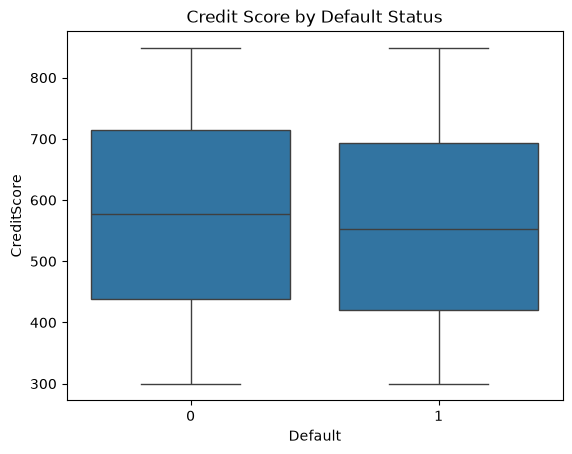

In [40]:
sns.boxplot(data=loan_dataset, x="Default", y="CreditScore")

plt.title("Credit Score by Default Status")
plt.show()

In [41]:
loan_dataset.groupby("Default")["CreditScore"].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,576.232270,158.849404,300.0,439.0,577.0,714.0,849.0
1,29653.0,559.286143,158.521855,300.0,421.0,553.0,693.0,849.0


### Observation

The distribution of credit scores slightly differs between borrowers who defaulted and those who did not.

Borrowers who defaulted had lower median credit score of 553 compared with 577 for borrowers who did not default. The mean credit score was also lower among borrowers who defaulted (approximately 559 compared with 576).

Although the distributions overlap considerably, the results suggest that lower credit scores are associated with greater occurence of default in this dataset.

This analysis shows an association between credit scores and default, but it does not establish that a lower credit score causes a borrower to default.

## Question 4 - Is income associated with loan default?

Income is an important borrower characteristic that may differ between borrowers who defaulted and those who did not. I will compare the income distribution between two default groups.

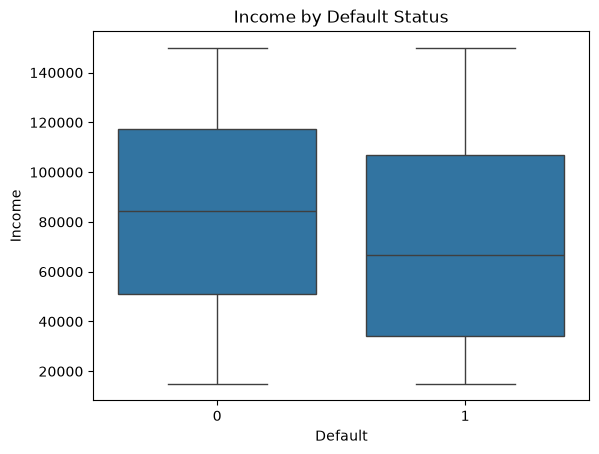

In [42]:
sns.boxplot(data=loan_dataset, x="Default", y="Income")

plt.title("Income by Default Status")
plt.show()

In [43]:
loan_dataset.groupby("Default")["Income"].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,83899.165995,38498.801232,15000.0,50994.0,84237.5,117186.75,149999.0
1,29653.0,71844.722659,40785.099507,15004.0,34022.0,66566.0,106895.00,149995.0


### Observation

The distribution of income differs between borrowers who defaulted and those who did not.

Borrowers who defaulted had a lower median income of £66,566 compared with £84,238 for borrowers who did not default. The mean credit score was also lower among borrowers who defaulted, at approximately £71,845 compared with £83,899.

Although the distributions overlap considerably, the results suggest that lower incomes are associated with greater occurence of default in this dataset.

This analysis shows an association between income and default, but it does not establish that a lower income causes a borrower to default.

## Question 5 - Is interest rate associated with loan default?

Interest rates may differ between borrowers who defaulted and those who did not. I will compare the interest rate distribution between two default groups.

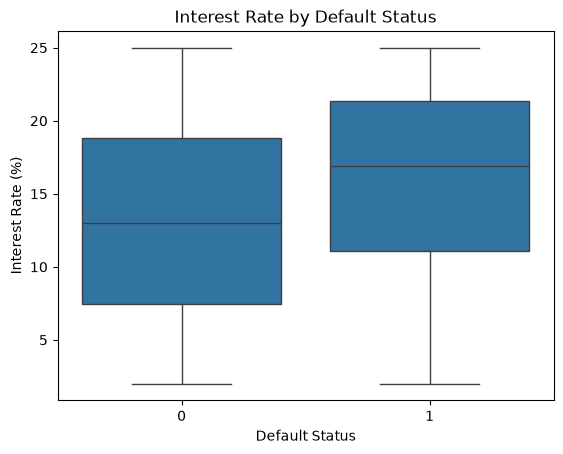

In [46]:
sns.boxplot(data=loan_dataset, x="Default", y="InterestRate")

plt.title("Interest Rate by Default Status")
plt.ylabel("Interest Rate (%)")
plt.xlabel("Default Status")
plt.show()

In [45]:
loan_dataset.groupby("Default")["InterestRate"].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,13.176994,6.612265,2.0,7.45,12.99,18.85,25.0
1,29653.0,15.896227,6.320304,2.0,11.06,16.93,21.36,25.0


### Observation

The distribution of interest rates differs between borrowers who defaulted and those who did not.

Borrowers who defaulted had a higher median interest rate of 16.93% compared with 12.99% for borrowers who did not default. The mean interest rate was also higher among borrowers who defaulted, at approximately 15.90% compared with 13.18%.
The results suggest that higher interest rates are associated with a greater occurrence of default in this dataset.

However, the distributions overlap, and this analysis does not establish that higher interest rates cause a borrwer to default. 

## Question 5 - Is debt-to-income ratio associated with loan default?

The debt-to-income ratio provides an indication of a borrower's existing debt relative to their income.  I will compare DTI ratios between borrowers who defaulted and those who did not.

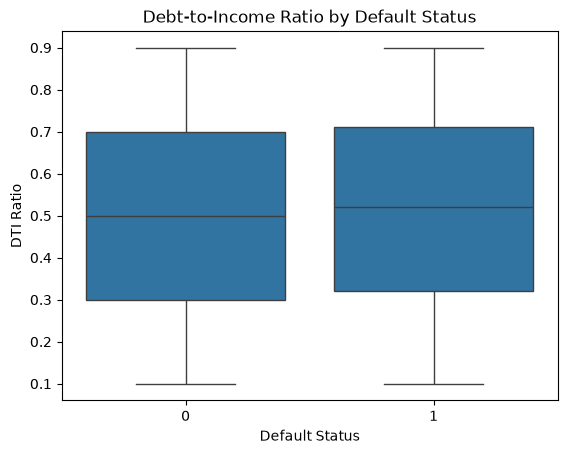

In [9]:
sns.boxplot(data=loan_dataset, x="Default", y="DTIRatio")

plt.title("Debt-to-Income Ratio by Default Status")
plt.ylabel("DTI Ratio")
plt.xlabel("Default Status")

plt.show()


In [10]:
loan_dataset.groupby("Default")["DTIRatio"].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,225694.0,0.498602,0.231099,0.1,0.30,0.50,0.70,0.9
1,29653.0,0.512467,0.229160,0.1,0.32,0.52,0.71,0.9


### Observation

The distribution of debt-to-income ratios differs slightly between borrowers who defaulted and those who did not.

Borrowers who defaulted had a median DTI ratio of 0.52, compared with 0.50 for borrowers who did not default. The mean DTI ratio was also slightly higher amongn borrowers who defaulted, at approximately 0.513 compared with 0.499.

The difference between the groups is relatively small compared with some of the other variables analysed. The results suggest a slight association between higher DTI ratios and loan default in this dataset, but do not establish that a higher DTI ratio causes default. 

## Question 7 - Does loan default vary by employment type?

The dataset contains several employment categories. I will examine the proportion of borrowers who default within each employment to determine whether default rates differ between groups.

In [13]:
default_by_employment = pd.crosstab(
    loan_dataset["EmploymentType"],
    loan_dataset["Default"],
    normalize="index"
) * 100

default_by_employment

Default,0,1
EmploymentType,,
Full-time,90.536634,9.463366
Part-time,88.034787,11.965213
Self-employed,88.537971,11.462029
Unemployed,86.447105,13.552895


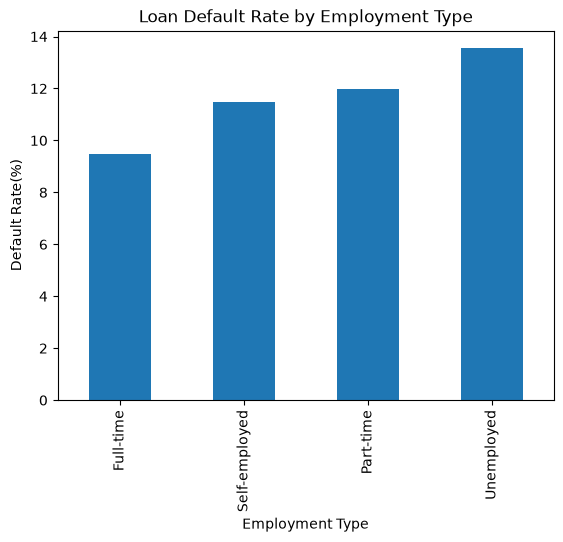

In [16]:
default_by_employment[1].sort_values().plot(
    kind="bar"
)

plt.title("Loan Default Rate by Employment Type")
plt.ylabel("Default Rate(%)")
plt.xlabel("Employment Type")

plt.show()

## Question 8 - Does loan default vary by the purpose of the loan?

Borrowers may take out loans for different reasons. I will compare the default rate across loan-purpose categories to identify whether default rates vary between groups.

In [17]:
default_by_purpose = pd.crosstab(
    loan_dataset["LoanPurpose"],
    loan_dataset["Default"],
    normalize="index"
) * 100

default_by_purpose

Default,0,1
LoanPurpose,,
Auto,88.118559,11.881441
Business,87.673983,12.326017
Education,88.161945,11.838055
Home,89.765238,10.234762
Other,88.211494,11.788506


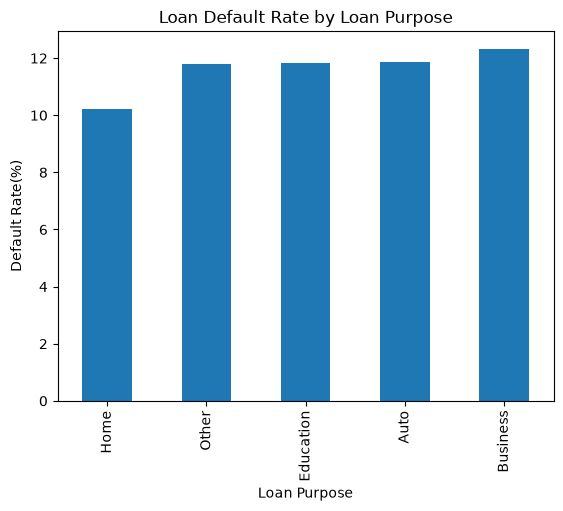

In [18]:
default_by_purpose[1].sort_values().plot(
    kind="bar"
)

plt.title("Loan Default Rate by Loan Purpose")
plt.ylabel("Default Rate(%)")
plt.xlabel("Loan Purpose")

plt.show()

### Observation

Default rates varied across loan purposes, although the differences were relatively small.

The 'Home' category had the lowest observed default rate at 10.23% whilst 'Business' loans had the highest at 12.33%. The other categories had default rates between these values.

The difference between the highest and lowest default rates was approximately 2.1%.

This suggest that loan prpose is associated with some variation in default rates in this dataset althoughh the differences between categories are relatively small.

## 5. Correlation Analysis

The previous analysis examined individual variables and their relationship with loan default. I will now investigate relationships between numerical variables using a correlation matrix.

In [19]:
numeric_columns = loan_dataset.select_dtypes(include="number")

correlation = numeric_columns.corr()

correlation

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,-0.167783
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.099119
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.086659
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,-0.034166
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,-0.097374
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.028330
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.131273
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000545
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,0.019236
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,0.000545,0.019236,1.000000


This creates a table showing the correlation between all the numerical variables.

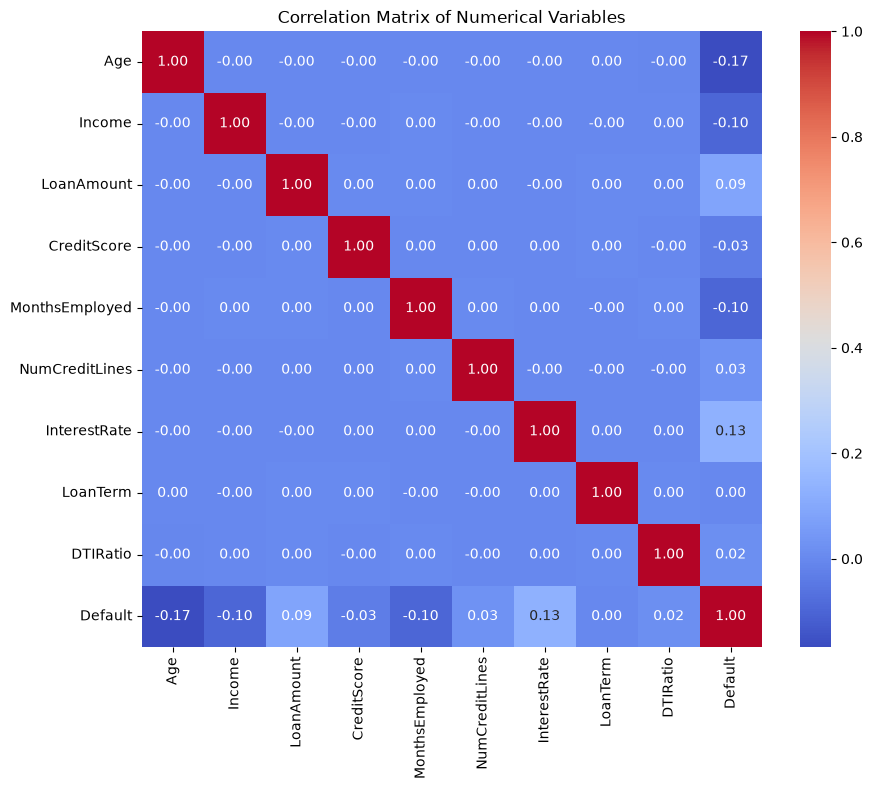

In [21]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()